# Part D: Sequence Modeling Concepts

---

## Audio is a Sequence, Not an Image

When you work with images, a pixel at position (100, 200) has no inherent relationship to a pixel at (100, 201) beyond spatial proximity. You can flip an image horizontally and it's still recognizable. The spatial structure matters, but there's no *direction* to it.

Audio is fundamentally different. Sample 5000 comes *after* sample 4999 and *before* sample 5001. That order is not arbitrary — it carries meaning. A syllable "ba" played forward sounds completely different from "ab" played backward. The **temporal order is the information**.

This is why audio is modeled as a **sequence** — like text, where word order determines meaning, not like an image where you could shuffle regions around.

The consequence for your network: it needs to understand not just *what* is happening at each moment, but *how things relate across time*. A speaker's voice at frame 50 is related to their voice at frame 48, 30, and even frame 5. The network needs to capture these **temporal dependencies**.

---

## Temporal Dependencies in Speech

Speech has structure at multiple timescales simultaneously:

```
~1ms   (16 samples):    Individual pitch period — one cycle of vocal cord vibration
~25ms  (400 samples):   One phoneme frame — "the 'ah' sound"
~100ms (1600 samples):  One syllable — "ba", "na", "the"
~300ms (4800 samples):  One word — "hello", "because"
~3s    (48000 samples): One utterance — a full sentence
```

For speaker diarization (your EEND task), the network needs to answer: "who is speaking at this moment?" That question requires understanding:
- **Local context** (~25ms): what does the voice sound like right now?
- **Medium context** (~300ms): is this consistent with the last few words?
- **Global context** (~3s): have I heard this voice before in this clip?

A network that can only see 25ms at a time can identify that *someone* is speaking, but can't reliably say *who*. To say who, it needs to compare current speech with speech heard earlier — which requires a large receptive field.

---

## Receptive Field: The Formal Calculation

You built a receptive field calculator in Part C1. Now let's understand the general formula more deeply.

For a stack of Conv1D layers, the receptive field grows based on three things per layer: kernel size, dilation, and stride. The formula you used:

```
RF  = RF_prev + (kernel_size - 1) × dilation × jump
jump_new = jump_prev × stride
```

`jump` is the key concept you might not have fully internalized yet. It tracks **how many input samples correspond to one step in the current layer's output**. It starts at 1 (one output step = one input sample) and multiplies by stride at every layer.

Why does jump matter? Because when a layer has `kernel_size=3`, it looks at 3 consecutive values in its input — but each of those values might already represent multiple original input samples. The receptive field growth is `(kernel_size - 1) × dilation × jump`, not just `(kernel_size - 1) × dilation`, because each step in the current layer covers `jump` original samples.

**Example — two strided layers:**

```
Layer 1: kernel=3, stride=2, dilation=1
  RF   = 1 + (3-1) × 1 × 1 = 3
  jump = 1 × 2 = 2

Layer 2: kernel=3, stride=2, dilation=1
  RF   = 3 + (3-1) × 1 × 2 = 7
  jump = 2 × 2 = 4
```

After two strided layers, looking at 3 consecutive values in layer 2's output covers 7 original input samples — because each step in layer 2 already represents 2 original samples.

**Example — Conv-TasNet's actual encoder + one TCN block:**

```
Encoder:  kernel=16, stride=8, dilation=1
  RF   = 1 + (16-1) × 1 × 1 = 16
  jump = 1 × 8 = 8              ← one TCN step = 8 original samples

TCN layer 1: kernel=3, stride=1, dilation=1
  RF   = 16 + (3-1) × 1 × 8 = 32

TCN layer 2: kernel=3, stride=1, dilation=2
  RF   = 32 + (3-1) × 2 × 8 = 64

TCN layer 3: kernel=3, stride=1, dilation=4
  RF   = 64 + (3-1) × 4 × 8 = 128
...
```

Each doubling of dilation doubles the RF growth per layer. After 8 TCN layers with one encoder: RF ≈ 4096 samples = 256ms. After 3 full TCN stacks: RF ≈ 24,576 samples = 1.5 seconds.

---

## Why Conv-TasNet Stacks Many Layers

You might ask: why not just use one massive dilated conv with dilation=128 instead of 8 layers of increasing dilation?

Three reasons:

**1. Hierarchy of features**

Each layer in the stack learns to detect patterns at a different timescale. Early layers (small dilation) detect local patterns — a pitch period, a consonant burst. Later layers (large dilation) combine those local detections into larger structures — a vowel, a syllable, a speaker turn. This hierarchy is the same reason deep networks outperform shallow ones: each layer builds on the abstractions from the one before.

**2. Non-linearity between layers**

Between every two conv layers there's a non-linearity (ReLU, PReLU, etc.) and often normalization. This means the stack of 8 dilated layers is not equivalent to one large layer — the intermediate non-linearities allow the network to represent much more complex functions. One layer with dilation=128 is still a *linear* operation; 8 layers with non-linearities between them are not.

**3. Parameter efficiency**

Eight layers of `kernel_size=3` = `8 × 3 = 24` parameters per channel (ignoring channels). One layer of `kernel_size=257` (equivalent receptive field without dilation) = `257` parameters per channel. Stack this over 256 channels and the difference is enormous.

---

## Global vs Local Context

These two terms come up constantly in audio ML papers and it's worth being precise about what they mean.

**Local context:** information from a small window around the current time step. A conv layer with small kernel or small dilation captures local context. It answers questions like "what phoneme is being spoken right now?"

**Global context:** information from the entire sequence. It answers questions like "have I heard this speaker before in this recording?" or "what's the dominant speaker for this whole clip?"

Pure convolutional networks — even with large receptive fields — are still fundamentally *local* processors. Each output position is only influenced by a fixed window of input positions. If the receptive field is 1.5 seconds but your clip is 3 seconds, the second half of the network's outputs have no knowledge of the first half's content.

For EEND, global context is critical — to assign consistent speaker labels throughout a recording, the network must be able to compare current speech to speech from much earlier. This is one reason EEND uses **Transformer attention** on top of its convolutional features. Attention can connect any two positions in the sequence regardless of distance — it's inherently global.

Conv-TasNet is primarily local — the TCN stack has a large but finite receptive field. This works for separation because you mostly need to separate overlapping voices in a short window, not track identities over a long recording.

```
Your system:
  Conv-TasNet (separation):  local context is enough
    → TCN with dilated convs
  
  EEND (diarization):        needs global context
    → LMF features + Transformer attention
```

This distinction will matter when you build the attention mechanism in Part E.

---

## TODOs

One TODO this time — Part D is more conceptual than mechanical, and the right exercise is to build something that makes the theory concrete in one integrated experiment.

---

### TODO: Receptive Field Visualizer

**Goal:** Build a complete receptive field analysis for a mini Conv-TasNet-style architecture. Visualize how the RF grows layer by layer, and verify it with an impulse test.

**Requirements:**

**Part 1 — Architecture definition:**

Define a small TCN-style stack as a list of layer configs:
- Encoder: `kernel=16, stride=8, dilation=1`
- TCN layers × 8: `kernel=3, stride=1, dilation` doubles each layer (1, 2, 4, 8, 16, 32, 64, 128)

Use your `receptive_field()` function from Part C1 — but modify it to return the RF *at each layer*, not just the final value. So it returns a list like `[16, 32, 64, ...]`.

**Part 2 — Visualization:**

Plot RF growth as a line chart (layer index on x-axis, RF in milliseconds on y-axis). Add a horizontal dashed line at 100ms, 500ms, and 1500ms so you can see which layer the network "crosses" each threshold.

**Part 3 — Impulse verification:**

Build the actual PyTorch model as `nn.Sequential` with the encoder + 8 TCN layers (use standard `Conv1d` for now, no depthwise-separable needed). All weights initialized randomly (default).

Run an impulse signal `(1, 1, 48000)` with a single `1.0` at position 24000 (middle of the signal) through the entire stack. Find the non-zero output positions. The span of those positions (max - min) should approximately match your calculated RF divided by the encoder's jump (since after the encoder, each output step = 8 input samples).

**Hints:**
- To return per-layer RF, collect `rf` into a list inside the loop before updating it
- For the plot: `plt.axhline(y=100, linestyle='--', label='100ms')` draws a horizontal line
- Convert RF from samples to ms: `rf_ms = rf / 16000 * 1000`
- For the impulse test: after the encoder (stride=8), the impulse at sample 24000 becomes approximately at position `24000 // 8 = 3000` in the encoded sequence
- With random weights, almost all output positions will be non-zero due to floating point — use a threshold: `torch.abs(output) > 1e-6` instead of exact non-zero

**Key questions:**
- At which layer does the RF first exceed 100ms?
- How does the RF growth rate change as dilation doubles — is it linear or something else?
- Does the impulse span in the output match what your formula predicts?

In [215]:
import torch
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torchaudio.transforms as T
import math
from pathlib import Path
import os
import sys
import json
import matplotlib.pyplot as plt

# Check if __file__ exists (it won't in Jupyter)
try:
    current_dir = Path(__file__).parent
except NameError:
    # If in Jupyter, use the current working directory
    current_dir = Path(os.getcwd())

# Add project root to Python path
project_root = current_dir.parent.parent.parent
sys.path.insert(0, str(project_root))

from src.preprocessing.audio_utils import load_audio


# Device configuration (for your MacBook)
if torch.backends.mps.is_available():
    device = torch.device('mps')
    print("✅ Using Apple Silicon GPU")
elif torch.cuda.is_available():
    device = torch.device('cuda')
    print("✅ Using NVIDIA GPU")
else:
    device = torch.device('cpu')
    print("⚠️ Using CPU")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")


✅ Using Apple Silicon GPU
PyTorch version: 2.10.0
Device: mps


In [216]:
class SpeakerDataset(torch.utils.data.Dataset):
    def __init__(self, manifest_path, limit=None):
        # Load manifest JSON
        # Store all entries as self.data
        with open(manifest_path, "r") as f:
            full_data = json.load(f)
        
        if limit:
            self.data = full_data[:limit]
        else:
            self.data = full_data
    
    def __len__(self):
        # Return number of samples
        return len(self.data)
    
    def __getitem__(self, idx):
        # Get entry at index idx
        # Load audio from disk
        # Extract features
        # Get label (num_speakers - 1)
        # Return (features, label)
        entry = self.data[idx]
        mixture_path = Path(entry['mixture_path'])
        mixture_audio, _ = load_audio(mixture_path)
        mixture_tensor = torch.from_numpy(mixture_audio)
        
        max_len = 48000
        
        if mixture_tensor.size(0) > max_len:
            # Truncate if too long
            mixture_tensor = mixture_tensor[:max_len]
        else:
            # Pad with zeros if too short
            padding = max_len - mixture_tensor.size(0)
            mixture_tensor = torch.nn.functional.pad(mixture_tensor, (0, padding))
        
        mixture_tensor = mixture_tensor.unsqueeze(0)
        
        speaker_count = int(entry['num_speakers']) - 1
        label_tensor = torch.tensor(speaker_count, dtype=torch.long)
        
        return mixture_tensor, label_tensor

In [217]:
train_manifest_path = Path.cwd().parent.parent.parent / "data" / "processed" / "train" / "train_manifest.json"
train_dataset = SpeakerDataset(train_manifest_path)
print(len(train_dataset))

val_manifest_path = Path.cwd().parent.parent.parent / "data" / "processed" / "val" / "val_manifest.json"
val_dataset = SpeakerDataset(val_manifest_path, 2000)
print(len(val_dataset))

10000
2000


In [218]:
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    drop_last=True
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    drop_last=False
)

### todo 1
part 1

In [219]:
def receptive_field(layers):
    rf_list = []
    rf = 1
    jump = 1
    for layer in layers:
        rf += (layer['kernel_size'] - 1) * layer['dilation'] * jump
        jump = jump * layer['stride']
        rf_list.append(rf)
    
    return rf_list

In [220]:
Architecture = [
    {"kernel_size": 16, "stride": 8, "dilation": 1},    #encoder
    {"kernel_size": 3, "stride": 1, "dilation": 1},    #TCN block layer 1
    {"kernel_size": 3, "stride": 1, "dilation": 2},    #TCN block layer 2
    {"kernel_size": 3, "stride": 1, "dilation": 4},    #TCN block layer 3
    {"kernel_size": 3, "stride": 1, "dilation": 8},    #TCN block layer 4
    {"kernel_size": 3, "stride": 1, "dilation": 16},   #TCN block layer 5
    {"kernel_size": 3, "stride": 1, "dilation": 32},   #TCN block layer 6
    {"kernel_size": 3, "stride": 1, "dilation": 64},   #TCN block layer 7
    {"kernel_size": 3, "stride": 1, "dilation": 128}   #TCN block layer 8
]

In [221]:
rf_values = receptive_field(Architecture)

print(rf_values)

[16, 32, 64, 128, 256, 512, 1024, 2048, 4096]


part 2

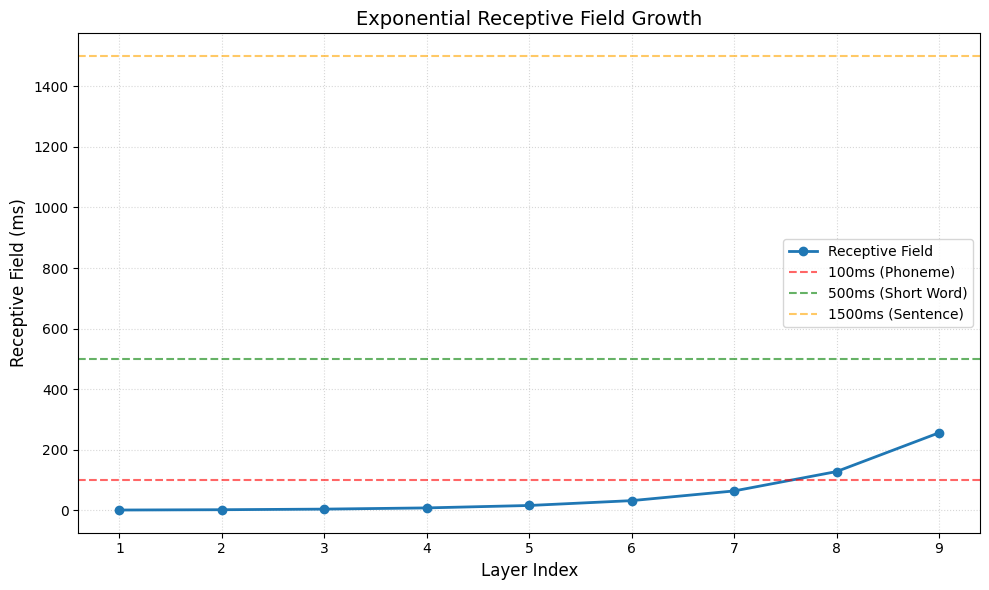

In [222]:
import matplotlib.pyplot as plt

# 1. Convert samples to milliseconds (assuming 16kHz)
sample_rate = 16000
rf_ms = [(s / sample_rate) * 1000 for s in rf_values]
layer_indices = list(range(1, len(Architecture) + 1))

# 2. Create the plot
plt.figure(figsize=(10, 6))
plt.plot(layer_indices, rf_ms, marker='o', linewidth=2, label='Receptive Field')

# 3. Add Threshold Lines
plt.axhline(y=100, color='r', linestyle='--', alpha=0.6, label='100ms (Phoneme)')
plt.axhline(y=500, color='g', linestyle='--', alpha=0.6, label='500ms (Short Word)')
plt.axhline(y=1500, color='orange', linestyle='--', alpha=0.6, label='1500ms (Sentence)')

# 4. Formatting
plt.title("Exponential Receptive Field Growth", fontsize=14)
plt.xlabel("Layer Index", fontsize=12)
plt.ylabel("Receptive Field (ms)", fontsize=12)
plt.xticks(layer_indices)
plt.legend()
plt.grid(True, which='both', linestyle=':', alpha=0.5)

plt.tight_layout()

part 3

In [223]:
class DilatedTemporalEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=16, stride=8, dilation=1, bias=False),     #encoder
            nn.Conv1d(16, 16, kernel_size=3, stride=1, dilation=1, bias=False),     #TCN block layer 1
            nn.Conv1d(16, 16, kernel_size=3, stride=1, dilation=2, bias=False),     #TCN block layer 2
            nn.Conv1d(16, 16, kernel_size=3, stride=1, dilation=4, bias=False),     #TCN block layer 3
            nn.Conv1d(16, 16, kernel_size=3, stride=1, dilation=8, bias=False),     #TCN block layer 4
            nn.Conv1d(16, 16, kernel_size=3, stride=1, dilation=16, bias=False),    #TCN block layer 5
            nn.Conv1d(16, 16, kernel_size=3, stride=1, dilation=32, bias=False),    #TCN block layer 6
            nn.Conv1d(16, 16, kernel_size=3, stride=1, dilation=64, bias=False),    #TCN block layer 7
            nn.Conv1d(16, 16, kernel_size=3, stride=1, dilation=128, bias=False),   #TCN block layer 8
        )
    
    def forward(self, x):
        return self.feature_extractor(x)

In [224]:
signal = torch.zeros(1, 1, 48000)
signal[0, 0, 24000] = 1.0

model = DilatedTemporalEncoder()

model.eval()
with torch.no_grad():
    output = model(signal)

threshold = 1e-6
time_mask = (torch.abs(output) > threshold).squeeze().any(dim=0)
non_zero_indices = torch.nonzero(time_mask).flatten()

expected_span = rf_values[-1] / 8
actual_span = (non_zero_indices.max() - non_zero_indices.min()).item()

print(f"Non-zero output span: {actual_span}")
print(f"Expected span (RF / Stride): ~{expected_span:.2f}")

assert abs(actual_span - expected_span) < 5, f"RF mismatch! Actual: {actual_span}, Expected: {expected_span}"

Non-zero output span: 511
Expected span (RF / Stride): ~512.00
